In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


DATA_DIR = 'data'
FILE_NAME = 'HAM10000_metadata.csv' 


file_path = os.path.join(DATA_DIR, FILE_NAME)

df = pd.read_csv(file_path)

print("5 dòng đầu dữ liệu")
display(df.head())

print("Info:  ")
df.info()

5 dòng đầu dữ liệu


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


Info:  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10124 entries, 0 to 10123
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10124 non-null  object 
 1   image_id      10124 non-null  object 
 2   dx            10124 non-null  object 
 3   dx_type       10124 non-null  object 
 4   age           10067 non-null  float64
 5   sex           10124 non-null  object 
 6   localization  10124 non-null  object 
 7   dataset       10124 non-null  object 
dtypes: float64(1), object(7)
memory usage: 632.9+ KB


C:\Users\nguye\AppData\Local\Temp\ipykernel_23756\2852637041.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis', ax=axes[0])


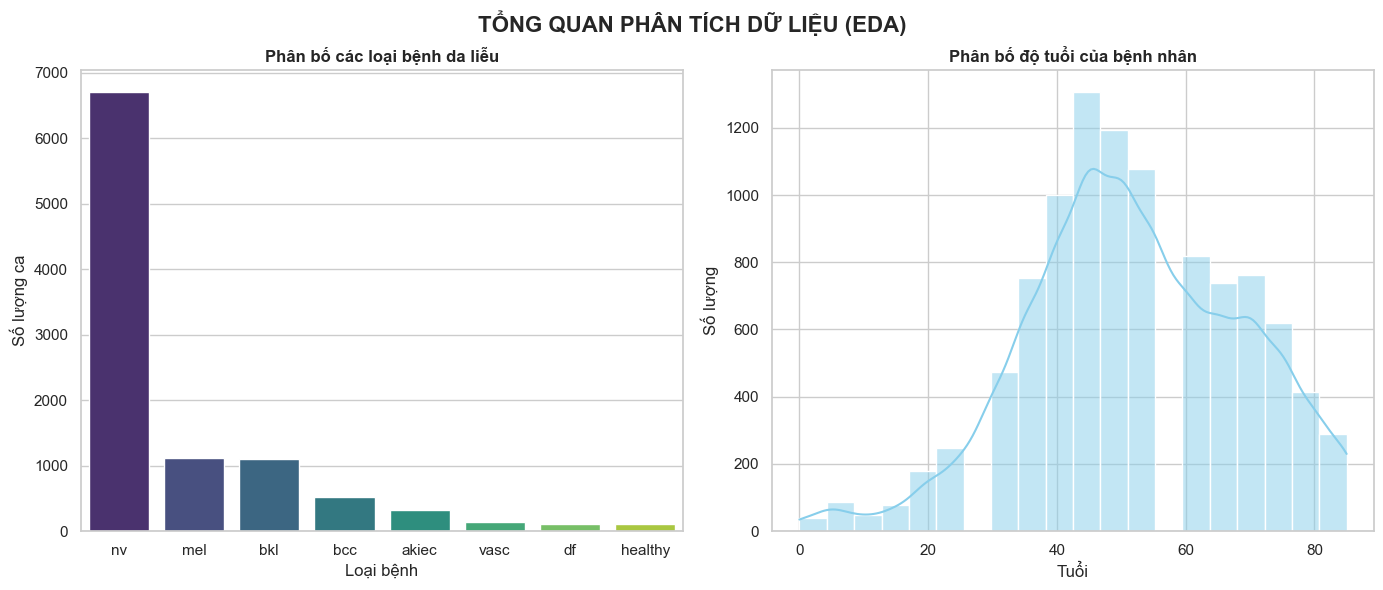

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Thiết lập phong cách chung cho các biểu đồ
sns.set_theme(style="whitegrid")
# Chỉnh lại kích thước (rộng x cao) cho phù hợp với 1 hàng ngang
plt.rcParams['figure.figsize'] = (14, 6) 

fig, axes = plt.subplots(1, 2)
fig.suptitle('TỔNG QUAN PHÂN TÍCH DỮ LIỆU (EDA)', fontsize=16, fontweight='bold')

# 1. Biểu đồ đếm số lượng các loại bệnh (Cột 'dx')
# LƯU Ý: Đã sửa thành axes[0]
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis', ax=axes[0])
axes[0].set_title('Phân bố các loại bệnh da liễu', fontweight='bold')
axes[0].set_xlabel('Loại bệnh')
axes[0].set_ylabel('Số lượng ca')

# 2. Phân bố độ tuổi của bệnh nhân (Cột 'age')
# LƯU Ý: Đã sửa thành axes[1]
sns.histplot(data=df, x='age', bins=20, kde=True, color='skyblue', ax=axes[1])
axes[1].set_title('Phân bố độ tuổi của bệnh nhân', fontweight='bold')
axes[1].set_xlabel('Tuổi')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.subplots_adjust(top=0.88) # Để tiêu đề tổng không bị đè
plt.show()

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Kiểm tra và xử lý missing value (SimpleImputer)
imputer = SimpleImputer(strategy='mean')
df['age'] = imputer.fit_transform(df[['age']])

# 2. Biến đổi cột dx thành diagnosis (theo mapping dx_dict)
dx_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
df['diagnosis'] = df['dx'].map(dx_dict)

# 3. Encode các biến phân loại bằng LabelEncoder
le = LabelEncoder()
categorical_cols = ['sex', 'localization', 'dx_type', 'diagnosis']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
X = df[['age', 'sex', 'localization', 'dx_type']]
y = df['diagnosis']  # Label nhãn bệnh

# 4. Chuẩn hóa dữ liệu với StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
import pickle

# tạo 1 df mới để dễ dàng lưu trữ và không cần lưu những cột chữ chỉ lưu những cột cần để train model 
X_df = pd.DataFrame(X_scaled, columns=['age', 'sex', 'localization', 'dx_type'])

# tạo cột nhãn cho model binary
binary_dict = {'mel': 1, 'bcc': 1, 'akiec': 1, 'vasc': 1, 'nv': 0, 'df': 0, 'bkl': 0}
X_df['y_binary'] = df['dx'].astype(str).str.strip().map(binary_dict).values

#tạo cột nhãn cho model đa lớp 
X_df['y_multi'] = df['diagnosis']

if X_df['y_binary'].isnull().sum() > 0:
    X_df = X_df.dropna(subset=['y_binary'])
    
X_df = X_df.reset_index(drop=True)

processed_file_path = os.path.join('data', 'processed_data.csv')
X_df.to_csv(processed_file_path, index=False)

# IN RA KIỂM TRA CHO CHẮC CÚ
print("Số lượng NaN trong y_binary:", X_df['y_binary'].isnull().sum())
print("Số lượng NaN trong y_multi:", X_df['y_multi'].isnull().sum())

os.makedirs('models', exist_ok=True)
tools = {
    'imputer': imputer,
    'scaler': scaler,
}
with open(os.path.join('models', 'preprocessing_tools.pkl'), 'wb') as f:
    pickle.dump(tools, f)

Số lượng NaN trong y_binary: 0
Số lượng NaN trong y_multi: 0
